<a href="https://colab.research.google.com/github/VivekAChawla/camm_hackathon/blob/k4my4r/docs/day_13_08052026/CAMM_hackaton_Day13_VChawla.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CAMM Hackathon 13: Two Previous Problems Revisited with Agents

In this notebook we revisit two problems from earlier CAMM hackathons and suggest solving them again, but this time with an **agentic approach**.

## What is an agent?

For this hackathon, an agent is an LLM-based system that can **plan**, **use tools**, **inspect intermediate results**, and **iterate** toward a goal instead of producing only one direct answer.

A simple agent loop is:

1. observe the current state
2. decide what to do next
3. call a tool or run code
4. evaluate the result
5. revise the plan if needed

## Good starting references

- Anthropic, [Building Effective Agents](https://www.anthropic.com/engineering/building-effective-agents)
- OpenAI, [A Practical Guide to Building AI Agents](https://openai.com/business/guides-and-resources/a-practical-guide-to-building-ai-agents/)


In [ ]:
!pip install gpytorch


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 291.2/291.2 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.8/174.8 kB 8.9 MB/s eta 0:00:00


In [ ]:
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.ndimage import binary_dilation
from skimage.draw import line as draw_line


## Problem 1: STEM Image Restoration

This problem comes from [**CAMM Hackathon #10**](https://github.com/kbarakati/camm_hackathon/blob/k4my4r/docs/day_10_27032026/CAMM_hackaton_10_Image_Restoration.ipynb).

**Task:** given a 2D microscopy intensity image and a binary loss mask, reconstruct the missing regions and estimate uncertainty.


In [ ]:
image_files = {
    "graphene_2.h5": "14N5Vg7Baqj2OdvgTD1l9oaWWvNvPCpYs",
    "HAADF_21.h5": "1IB2Au4Dh7iNZCeOmj1dmaGB2JOIFAxoN",
}

for filename, file_id in image_files.items():
    if not Path(filename).exists():
        !gdown {file_id} -O "{filename}"
    else:
        print(f"Using existing file: {filename}")


Downloading...
From: https://drive.google.com/uc?id=14N5Vg7Baqj2OdvgTD1l9oaWWvNvPCpYs
To: /content/graphene_2.h5
100% 17.1M/17.1M [00:00<00:00, 117MB/s]
Downloading...
From: https://drive.google.com/uc?id=1IB2Au4Dh7iNZCeOmj1dmaGB2JOIFAxoN
To: /content/HAADF_21.h5
100% 4.53M/4.53M [00:00<00:00, 200MB/s]


In [ ]:
import json


def load_hdf5_to_dict(file_path):
    with h5py.File(file_path, "r") as f:
        return _load_item(f)


def _load_item(obj):
    if isinstance(obj, h5py.Group):
        keys = list(obj.keys())
        if len(keys) == 0 and "value" not in obj.attrs:
            return {}
        if all(k.isdigit() for k in keys):
            return [_load_item(obj[k]) for k in sorted(keys, key=lambda x: int(x))]
        out = {k: _load_item(obj[k]) for k in keys}
        if "value" in obj.attrs and obj.attrs["value"] == "None":
            return None
        return out

    if isinstance(obj, h5py.Dataset):
        data = obj[()]
        if np.isscalar(data):
            return data
        if isinstance(data, (bytes, np.bytes_)):
            try:
                return json.loads(data.decode())
            except Exception:
                return data.decode()
        if getattr(data, "dtype", None) is not None and data.dtype.kind == "S":
            try:
                return [json.loads(x.decode()) for x in data]
            except Exception:
                return [x.decode() for x in data]
        return data

    raise ValueError(f"Unknown HDF5 object type: {type(obj)}")


def mask_below_line(im, frac=0.6, above=True):
    h, w = im.shape
    row = int(frac * h)
    mask = np.zeros((h, w), dtype=bool)
    mask[:row, :] = True if above else False
    mask[row:, :] = False if above else True
    return mask


def mask_lines(im, n_lines=80, thickness=4, orientation="horizontal", seed=0):
    rng = np.random.default_rng(seed)
    h, w = im.shape
    mask = np.zeros((h, w), dtype=bool)
    orientations = ["horizontal", "vertical", "diagonal"]

    for _ in range(n_lines):
        ort = rng.choice(orientations) if orientation == "mixed" else orientation
        if ort == "horizontal":
            mask[rng.integers(0, h), :] = True
        elif ort == "vertical":
            mask[:, rng.integers(0, w)] = True
        else:
            r0, c0 = rng.integers(0, h), rng.integers(0, w)
            r1, c1 = rng.integers(0, h), rng.integers(0, w)
            rr, cc = draw_line(r0, c0, r1, c1)
            valid = (rr >= 0) & (rr < h) & (cc >= 0) & (cc < w)
            mask[rr[valid], cc[valid]] = True

    if thickness > 1:
        mask = binary_dilation(mask, structure=np.ones((thickness, thickness), dtype=bool))
    return ~mask


In [ ]:
data = load_hdf5_to_dict("graphene_2.h5")
data_more = load_hdf5_to_dict("HAADF_21.h5")

im0 = data["Measurement_000"]["Channel_000"]["HAADF"]["HAADF"][:1000, :1000]
im1 = data["Measurement_001"]["Channel_000"]["HAADF"]["HAADF"][:1000, :1000]
im2 = data["Measurement_001"]["Channel_000"]["HAADF"]["HAADF"][:1000, -1000:]
im3 = data_more["Measurement_000"]["Channel_000"]["HAADF"]["HAADF"]

ims = [im0, im1, im2, im3]


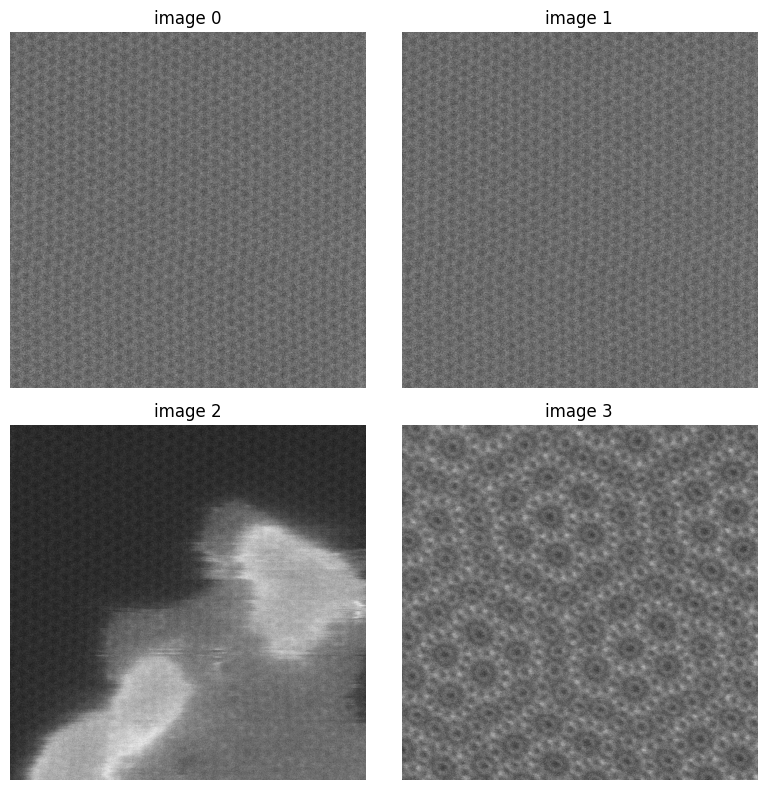

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(ims[i], cmap="gray")
    ax.set_title(f"image {i}")
    ax.axis("off")
plt.tight_layout()
plt.show()


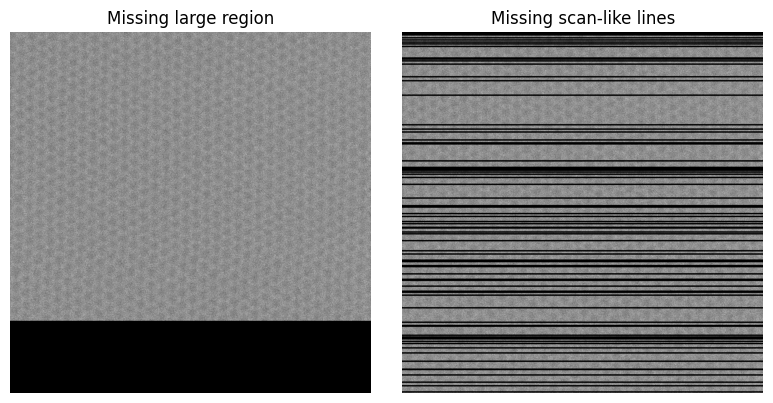

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(mask_below_line(im0, frac=0.8) * im0, cmap="gray")
ax[0].set_title("Missing large region")
ax[0].axis("off")

ax[1].imshow(mask_lines(im0, seed=0) * im0, cmap="gray")
ax[1].set_title("Missing scan-like lines")
ax[1].axis("off")
plt.tight_layout()
plt.show()


### Can we design an agent which will design and execute uncertanty aware image reconstruction framework?

## Problem 2: Active Experimental Design under Noise and Budget Constraints

This problem comes from [**CAMM Hackathon #11**](https://github.com/kbarakati/camm_hackathon/blob/k4my4r/docs/day_11_10042026/CAMM_Hackaton_11.ipynb).

**Task:** design a strategy that decides **where to measure**, **in what order**, and **for how long**, while accounting for measurement noise, limited budget, and movement cost.


### Minimal starter setup

The general setup cell above already installs the required packages. The cells below give a lightweight starting point for testing an adaptive measurement strategy.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import gpytorch


In [ ]:
# Example target functions for testing your strategy

def unimodal(x):
    return 1.2 * np.exp(-0.5 * ((x - 2.3) / 0.7) ** 2) + 0.1


def oscillatory(x):
    return 0.55 + 0.15 * np.sin(1.8 * x) + 0.08 * np.cos(6.0 * x)

def multimodal(x):
    x = np.asarray(x)
    res = 10 + x**2 - 7 * np.cos(2 * np.pi * x) + 9 * np.sin(1.4 * np.pi * x)
    return res/40


def double_well(x):
    x = np.asarray(x)
    res = 0.08 * (x**2 - 7)**2 + 0.45 * x

    return res/10

def broad_narrow(x):
    x = np.asarray(x)

    res = (
        1
        - 1.0 * np.exp(-((x - 2.5)**2) / (2 * 0.9**2))
        - 1.6 * np.exp(-((x - 1.0)**2) / (2 * 0.08**2))
    )
    return res


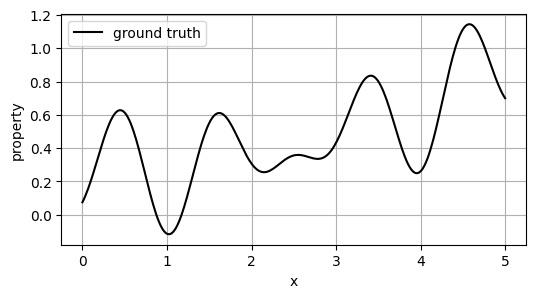

In [ ]:
x_grid = np.linspace(0, 5, 300)
f_true = multimodal

plt.figure(figsize=(6, 3))
plt.plot(x_grid, f_true(x_grid), 'k', label='ground truth')
plt.xlabel('x')
plt.ylabel('property')
plt.grid()
plt.legend()
plt.show()


In [ ]:

#@title simple noise models

def noise_constant(x = None, t = None, sigma0=0.1):
    t = np.asarray(t)
    return sigma0 * np.ones_like(t, dtype=float)

def noise_decay_floor(x = None, t = None, sigma_min=0.05, A=0.18, tau=1.0):
    t = np.asarray(t)
    return sigma_min + A * np.exp(-t / tau)

In [ ]:
# Simple budget accounting example
budget_total = 12.0
travel_weight = 0.15

# Example move from x=1.0 to x=3.5 with acquisition time 0.8
x_prev = 1.0
x_next = 3.5
acq_time = 0.8

travel_cost = travel_weight * abs(x_next - x_prev)
step_cost = acq_time + travel_cost
print('Example step cost:', round(step_cost, 3))
print('Remaining budget after step:', round(budget_total - step_cost, 3))


Example step cost: 1.175
Remaining budget after step: 10.825


In [ ]:

#@title measurement simulator

class MeasurementSimulator:
    def __init__(self, ground_truth_model, noise_model, rng=None, **noise_kwargs):
        """
        Parameters
        ----------
        ground_truth_model : callable
            Function f(x)
        noise_model : callable
            Function sigma(x, t, **noise_kwargs)
        rng : None, int, or np.random.Generator
            Random generator or seed
        **noise_kwargs
            Default parameters for noise_model
        """
        self.f = ground_truth_model
        self.noise_model = noise_model
        self.noise_kwargs = noise_kwargs

        if rng is None:
            self.rng = np.random.default_rng()
        elif isinstance(rng, (int, np.integer)):
            self.rng = np.random.default_rng(rng)
        else:
            self.rng = rng

    def measure(self, coords, **noise_kwargs):
        """
        coords : array of shape (N, 2)
            Columns are (x, t)

        Returns
        -------
        y_meas : array of shape (N,)
            Noisy measurements
        """
        coords = np.asarray(coords, dtype=float)

        if coords.ndim != 2 or coords.shape[1] != 2:
            raise ValueError("coords must have shape (N, 2)")

        x = coords[:, 0]
        t = coords[:, 1]

        kwargs = {**self.noise_kwargs, **noise_kwargs}
        sigma = np.asarray(self.noise_model(x, t, **kwargs), dtype=float)
        noise = self.rng.normal(0.0, sigma, size=len(x))

        return self.f(x) + noise

    __call__ = measure

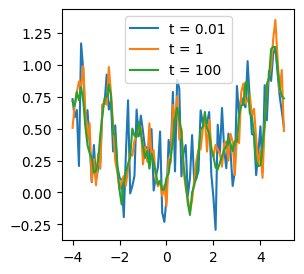

In [ ]:

#@title example: grid measurements with different acqusition time

x = np.linspace(-4,5, 100) #x grid

durations = [0.01, 1, 100] #select durations
model = multimodal #select model [unimodal, double_well, multimodal, broad_narrow]


sim_decay = MeasurementSimulator(
    ground_truth_model=model,
    noise_model=noise_decay_floor,
    rng=2,
)


fig, ax = plt.subplots(figsize=(3,3))

for d in durations:
  d_ar = np.ones(len(x))*d
  coords = np.vstack([x, d_ar]).T

  ax.plot(coords[:,0], sim_decay.measure(coords), label = f't = {d}')

ax.legend()

#### Can an agentic approach be useful for integration such experimental campaigns?

In [ ]:

B = 200 #your budget (can be different)

meas_sim = MeasurementSimulator(
    ground_truth_model=broad_narrow, #choose gt function
    noise_model=noise_decay_floor,  #choose noise model
    rng=123,
)

In [ ]:
!pip install openai

In [ ]:
import os
from getpass import getpass

os.environ["OPENAI_API_KEY"] = getpass("Enter OpenAI API key: ")

Enter OpenAI API key: ··········


In [ ]:
from openai import OpenAI
client = OpenAI()

response = client.responses.create(
    model="gpt-5.5",
    input="Say hello and explain what an experimental design agent is in one sentence."
)

print(response.output_text)

Hello! An experimental design agent is an AI system that helps plan, optimize, and analyze experiments by suggesting variables, conditions, controls, and workflows to efficiently test hypotheses.


In [ ]:
import json

prompt = """
You are an experimental design agent.

Choose the next measurement.
Return JSON only with:
{"x": float, "t": float, "reason": string}

Remaining budget: 10
Current x: 0.0
Allowed x range: 0 to 5
Allowed times: [0.05, 0.2, 0.8, 2.0]
"""

response = client.responses.create(
    model="gpt-5.5",
    input=prompt
)

action = json.loads(response.output_text)
print(action)

{'x': 2.5, 't': 0.8, 'reason': 'Start with a central x value and an intermediate-long time to obtain a broadly informative baseline before allocating remaining measurements to spatial or temporal extremes.'}


# Now lets test

In [ ]:
# create simulator
sim = MeasurementSimulator(
    ground_truth_model=multimodal,
    noise_model=noise_decay_floor,
    rng=123,
)

# history memory
history = []

In [ ]:
# take LLM action
x_next = action["x"]
t_next = action["t"]

# simulator expects [[x, t]]
coords = np.array([[x_next, t_next]])

# perform measurement
y_obs = sim.measure(coords)[0]

# compute sigma separately
sigma = noise_decay_floor(
    x=np.array([x_next]),
    t=np.array([t_next])
)[0]

print("Measured:")
print("x =", x_next)
print("t =", t_next)
print("y =", y_obs)
print("sigma =", sigma)


history.append({
    "x": float(x_next),
    "t": float(t_next),
    "y": float(y_obs),
    "reason": action["reason"]
})

Measured:
x = 2.47
t = 25.0
y = 0.3019224843670164
sigma = 0.05000000000249983


In [ ]:
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def extract_json(text):
    text = text.strip()
    text = re.sub(r"```json|```", "", text).strip()
    return json.loads(text)

def ask_agent(history, budget_remaining, step):
    prompt = f"""
You are an autonomous scientific measurement agent.

Goal:
Efficiently discover the shape of an unknown 1D function.

You do NOT know the ground truth function.
You do NOT know the noise model.
You only observe noisy measurements.

Current step: {step}
Budget remaining: {budget_remaining}

Measurement history:
{history}

Rules:
- x must be between 0 and 5
- t must be positive
- larger t usually gives more reliable measurement but costs more budget
- do not spend more than remaining budget
- balance exploration and exploitation

Return ONLY valid JSON:
{{
"x": float,
"t": float,
"reason": string
}}
"""
    response = client.responses.create(
        model="gpt-5-mini",
        input=prompt
    )

    return extract_json(response.output_text)


In [ ]:
budget_total

200

In [ ]:
# reset
history = []
budget_total = B
budget_remaining = budget_total
n_steps = 15

for step in range(n_steps):
    if budget_remaining <= 0:
        break

    action = ask_agent(history, budget_remaining, step)

    x_next = float(action["x"])
    t_next = float(action["t"])

    # safety clipping
    x_next = np.clip(x_next, 0, 5)
    t_next = min(max(t_next, 1e-6), budget_remaining)

    coords = np.array([[x_next, t_next]])
    y_obs = sim.measure(coords)[0]

    history.append({
        "step": step,
        "x": float(x_next),
        "t": float(t_next),
        "y": float(y_obs),
        "budget_remaining_before": float(budget_remaining),
        "budget_remaining_after": float(budget_remaining - t_next),
        "reason": action["reason"]
    })

    budget_remaining -= t_next

df_history = pd.DataFrame(history)
df_history

,step,x,t,y,budget_remaining_before,budget_remaining_after,reason
0,0,2.500,10.0,0.337858,200.0,190.0,Initial exploratory measurement at the midpoin...
1,1,0.000,15.0,0.139396,190.0,175.0,Explore the left boundary (x=0) to detect base...
2,2,5.000,20.0,0.709699,175.0,155.0,Explore the right boundary (x=5) to compare wi...
3,3,3.750,25.0,0.488475,155.0,130.0,Measure in the right-mid region (between 2.5 a...
4,4,1.250,30.0,0.158819,130.0,100.0,Probe the left-mid region (between x=0 and x=2...
5,5,4.375,35.0,0.906540,100.0,65.0,Recent measurements show a steady increase fro...
6,6,4.375,50.0,0.965461,65.0,15.0,Repeat measurement at x=4.375 to verify the un...
7,7,4.000,15.0,0.245182,15.0,0.0,Probe between x=3.75 (y≈0.488) and x=4.375 (tw...


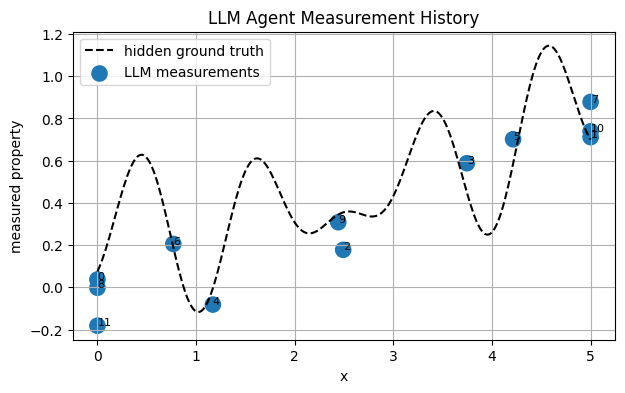

In [ ]:
x_grid = np.linspace(0, 5, 300)

plt.figure(figsize=(7, 4))

# only for evaluation/visualization, not given to LLM
plt.plot(x_grid, multimodal(x_grid), 'k--', label="hidden ground truth")

plt.scatter(
    df_history["x"],
    df_history["y"],
    s=40 + 80 * df_history["t"] / df_history["t"].max(),
    label="LLM measurements"
)

for _, row in df_history.iterrows():
    plt.text(row["x"], row["y"], int(row["step"]), fontsize=8)

plt.xlabel("x")
plt.ylabel("measured property")
plt.title("LLM Agent Measurement History")
plt.grid(True)
plt.legend()
plt.show()

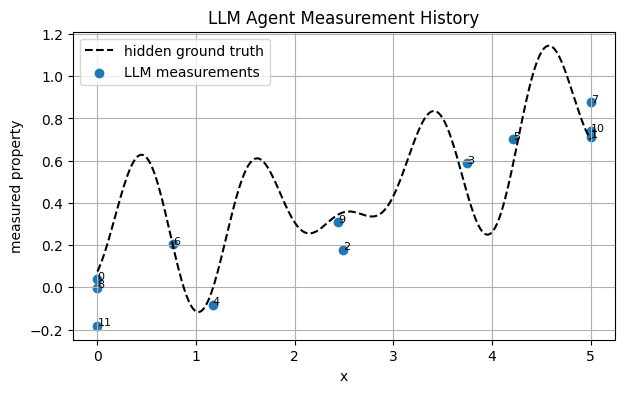

In [ ]:
x_grid = np.linspace(0, 5, 300)

plt.figure(figsize=(7, 4))
plt.plot(x_grid, multimodal(x_grid), 'k--', label="hidden ground truth")
plt.scatter(df_history["x"], df_history["y"], label="LLM measurements")

for _, row in df_history.iterrows():
    plt.text(row["x"], row["y"], int(row["step"]), fontsize=8)

plt.xlabel("x")
plt.ylabel("measured property")
plt.title("LLM Agent Measurement History")
plt.grid(True)
plt.legend()
plt.show()

# Now make it interact iwth code

# Module 2: 1D GP Belief Wrapper

## Overview

Module 2 provides the GP model used throughout all subsequent modules as the agent's belief about the unknown function. It wraps GPyTorch's exact GP with a `belief` parameter that controls how much the agent trusts its observations — affecting both initial noise level and initial lengthscale.

---

## Why a Belief Parameter

The same GP architecture serves different roles depending on how much the agent trusts its measurements:

- **High belief (→ 1.0):** assumes measurements are reliable → low initial noise, short initial lengthscale → GP fits data closely, allows sharp features
- **Low belief (→ 0.0):** assumes measurements are noisy → high initial noise, long initial lengthscale → GP smooths over data, produces broader predictions

This lets the agent reason about uncertainty under different trust assumptions, which is important for Module 3's Track 2 (adaptive belief selection).

---

## GP Architecture

**Model:** `StandardExactGP1D` — exact GP with constant mean and RBF (squared exponential) kernel  
**Kernel:** `ScaleKernel(RBFKernel)` with bounded lengthscale and outputscale  
**Likelihood:** `GaussianLikelihood` with bounded noise  
**Normalization:** `GPNormalizer1D` standardizes X and y before fitting, then inverts predictions back to original scale

```
Input: X ∈ R^(n×1), y ∈ R^n
Normalize: X_norm, y_norm
Fit GP: k(x,x') = sigma_f² * exp(-||x-x'||² / 2l²)
Predict: mean, var_latent, var_obs (in original y units)
```

---

## Belief → Hyperparameter Mapping

```python
# Initial noise (in original y units)
noise_init = noise_floor + (1 - belief) * (noise_ceiling - noise_floor)
# belief=1.0: noise = noise_floor = 1e-4  (trusts data)
# belief=0.0: noise = noise_ceiling = 0.25 (distrusts data)

# Initial lengthscale
l_init = min_lengthscale + (1 - belief) * 0.8
# belief=1.0: l = 0.05  (sharp features allowed)
# belief=0.0: l = 0.85  (smooth functions assumed)
```

Both noise and lengthscale are initialized from belief, then **learned** via marginal likelihood optimization. The belief just sets the starting point — the GP adapts from there based on the data.

---

## Hyperparameter Bounds

| Parameter | Lower bound | Upper bound |
|---|---|---|
| Noise (normalized) | `noise_floor / y_std²` | `noise_ceiling / y_std²` |
| Lengthscale | 0.05 | 8.0 |
| Outputscale | 1e-4 | 100.0 |

Bounds are enforced via GPyTorch `Interval` constraints. This prevents degenerate fits (zero noise, infinite lengthscale) that can occur with limited data.

---

## Training

```python
gp = train_gp_1d(X_obs, y_obs, belief=0.6, train_iters=80, lr=0.05)
```

Optimizer: Adam on all GP parameters (mean, kernel, likelihood noise)  
Loss: negative marginal log-likelihood (MLL)  
Minimum data: 2 observations required  

The `train_iters=60` used in Modules 7-8 is a deliberate tradeoff — enough to get reasonable hyperparameters without spending too much compute per step (GP is fit 2-3 times per step).

---

## Predictions

```python
pred = gp.predict(X_eval)  # X_eval shape (n, 1)
```

Returns:

| Key | Description |
|---|---|
| `mean` | GP posterior mean in original y units |
| `std_latent` | Latent posterior std (no obs noise) — used as uncertainty/acquisition |
| `std_obs` | Predictive std including obs noise — not used for acquisition |
| `var_latent`, `var_obs` | Squared versions of above |

`std_latent` is the key quantity — it represents the GP's epistemic uncertainty about f(x), which is what the agent wants to reduce.

---

## Debug Params

```python
gp.debug_params()
# Returns:
{
    "belief": 0.6,
    "noise_norm": 0.0012,        # fitted noise in normalized y space
    "outputscale": 1.43,         # sigma_f²
    "lengthscale": 0.31,         # l
    "init_lengthscale_from_belief": 0.45,
    "init_noise_raw_from_belief": 0.10,
}
```

These are the three GP hyperparameters used as features in Module 7/8's feature vector (indices 14-16).

---

## Grid Evaluation

```python
gp_eval = evaluate_gp_on_grid_1d(gp, env)
rmse, z_true = compute_rmse_on_grid_1d(gp_eval, env)
max_info = compute_max_location_success_1d(gp_eval, env)
```

`evaluate_gp_on_grid_1d` evaluates on `env.x_grid` — the full discrete grid. RMSE is computed against `env.true_field_initial` (the true function evaluated at initialization). Max location success checks if the GP's predicted argmax is within one grid spacing of the true argmax.

---

## Normalizer: `GPNormalizer1D`

Fits `x_mean, x_std, y_mean, y_std` from training data. All GP operations work in normalized space. Predictions are inverted back:

```python
mean_original = mean_normalized * y_std + y_mean
var_original  = var_normalized * y_std²
```

This keeps the GP numerically stable regardless of the function's amplitude or x-range.

---

## Usage

```python
# Fit GP at belief=0.6
gp = train_gp_1d(X_obs, y_obs, belief=0.6, train_iters=80, lr=0.05)

# Evaluate on grid
gp_eval = evaluate_gp_on_grid_1d(gp, env)
rmse, z_true = compute_rmse_on_grid_1d(gp_eval, env)

# Uncertainty curve for acquisition
unc = compute_uncertainty_curve_1d(gp, env)  # shape (nx,)

# GP hyperparameters for feature vector
params = gp.debug_params()  # noise_norm, lengthscale, outputscale
```

---

## File Structure

| Function/Class | Purpose |
|---|---|
| `StandardExactGPWrapper1D` | Main GP wrapper with belief control |
| `StandardExactGP1D` | GPyTorch model (mean + RBF kernel) |
| `GPNormalizer1D` | X and y standardization |
| `train_gp_1d` | Convenience training entry point |
| `evaluate_gp_on_grid_1d` | Evaluate on env.x_grid |
| `compute_rmse_on_grid_1d` | RMSE vs true field |
| `compute_max_location_success_1d` | Predicted max accuracy |
| `compute_uncertainty_curve_1d` | GP std across grid (acquisition) |
| `summarize_gp_for_context_1d` | Compact GP summary dict |


In [ ]:
# =========================================================
# MODULE 2: 1D GP belief wrapper
# belief affects BOTH:
#   1) observation noise trust
#   2) kernel smoothness via initial lengthscale
# =========================================================

import numpy as np
import torch
import gpytorch
from dataclasses import dataclass
from typing import Dict, Optional, Tuple


# ---------------------------------------------------------
# Small tensor helper
# ---------------------------------------------------------

def _to_float_tensor(x, device="cpu"):
    """
    Convert numpy array / list / tensor to float32 torch tensor.
    """
    if isinstance(x, torch.Tensor):
        return x.detach().clone().float().to(device)
    return torch.tensor(x, dtype=torch.float32, device=device)


# ---------------------------------------------------------
# Normalizer
# ---------------------------------------------------------

class GPNormalizer1D:
    """
    Standardize X and y before GP training.

    Even in 1D, normalization helps:
    - more stable training
    - better noise / lengthscale behavior
    """

    def __init__(self, eps: float = 1e-8):
        self.eps = eps
        self.x_mean = None
        self.x_std = None
        self.y_mean = None
        self.y_std = None

    def fit(self, X, y):
        X = np.asarray(X, dtype=np.float32).reshape(-1, 1)
        y = np.asarray(y, dtype=np.float32).reshape(-1)

        self.x_mean = X.mean(axis=0, keepdims=True)
        self.x_std = X.std(axis=0, keepdims=True)
        self.x_std[self.x_std < self.eps] = 1.0

        self.y_mean = float(y.mean())
        self.y_std = float(y.std())
        if self.y_std < self.eps:
            self.y_std = 1.0

    def transform_X(self, X):
        X = np.asarray(X, dtype=np.float32).reshape(-1, 1)
        return (X - self.x_mean) / self.x_std

    def transform_y(self, y):
        y = np.asarray(y, dtype=np.float32).reshape(-1)
        return (y - self.y_mean) / self.y_std

    def inverse_y(self, y_norm):
        y_norm = np.asarray(y_norm, dtype=np.float32)
        return y_norm * self.y_std + self.y_mean

    def variance_to_original(self, var_norm):
        var_norm = np.asarray(var_norm, dtype=np.float32)
        return var_norm * (self.y_std ** 2)


# ---------------------------------------------------------
# Belief config
# ---------------------------------------------------------

@dataclass
class GPBeliefConfig1D:
    """
    High-level GP config for 1D.

    belief:
        1.0 -> high trust in measurements
        0.0 -> low trust in measurements

    Lower belief:
    - higher initial noise
    - smoother GP tendency
    """
    belief: float = 0.5
    lr: float = 0.05
    train_iters: int = 120
    noise_floor: float = 1e-4
    noise_ceiling: float = 0.25
    min_lengthscale: float = 0.05
    max_lengthscale: float = 8.0
    init_outputscale: float = 1.0
    learn_noise: bool = True
    verbose: bool = False
    device: str = "cpu"


def make_belief_config_1d(
    belief: float,
    device: str = "cpu",
    lr: float = 0.05,
    train_iters: int = 120,
    noise_floor: float = 1e-4,
    noise_ceiling: float = 0.25,
    min_lengthscale: float = 0.05,
    max_lengthscale: float = 8.0,
    verbose: bool = False,
):
    """
    Convenience constructor.
    """
    belief = float(np.clip(belief, 0.0, 1.0))
    return GPBeliefConfig1D(
        belief=belief,
        lr=lr,
        train_iters=train_iters,
        noise_floor=noise_floor,
        noise_ceiling=noise_ceiling,
        min_lengthscale=min_lengthscale,
        max_lengthscale=max_lengthscale,
        init_outputscale=1.0,
        learn_noise=True,
        verbose=verbose,
        device=device,
    )


# ---------------------------------------------------------
# Exact GP model
# ---------------------------------------------------------

class StandardExactGP1D(gpytorch.models.ExactGP):
    """
    Exact GP in 1D with:
    - constant mean
    - RBF kernel
    - bounded lengthscale
    - bounded outputscale
    """

    def __init__(
        self,
        train_x,
        train_y,
        likelihood,
        min_lengthscale: float = 0.05,
        max_lengthscale: float = 8.0,
        init_lengthscale: float = 0.4,
        init_outputscale: float = 1.0,
    ):
        super().__init__(train_x, train_y, likelihood)

        self.mean_module = gpytorch.means.ConstantMean()

        base_kernel = gpytorch.kernels.RBFKernel(ard_num_dims=1)
        base_kernel.register_constraint(
            "raw_lengthscale",
            gpytorch.constraints.Interval(min_lengthscale, max_lengthscale),
        )

        self.covar_module = gpytorch.kernels.ScaleKernel(base_kernel)
        self.covar_module.register_constraint(
            "raw_outputscale",
            gpytorch.constraints.Interval(1e-4, 100.0),
        )

        self.covar_module.base_kernel.lengthscale = float(init_lengthscale)
        self.covar_module.outputscale = float(init_outputscale)

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)


# ---------------------------------------------------------
# GP wrapper
# ---------------------------------------------------------

class StandardExactGPWrapper1D:
    """
    1D GP wrapper with belief/trust control.

    belief in [0, 1]:
        1.0 -> trust observations strongly
        0.0 -> trust observations weakly

    Lower belief:
        - higher initial observation noise
        - larger initial lengthscale
        - less chasing noisy measurements
    """

    def __init__(
        self,
        device: str = "cpu",
        lr: float = 0.05,
        train_iters: int = 120,
        belief: float = 0.5,
        noise_floor: float = 1e-4,
        noise_ceiling: float = 0.25,
        min_lengthscale: float = 0.05,
        max_lengthscale: float = 8.0,
        init_outputscale: float = 1.0,
        verbose: bool = False,
        learn_noise: bool = True,
    ):
        self.device = device
        self.lr = lr
        self.train_iters = train_iters
        self.belief = float(np.clip(belief, 0.0, 1.0))
        self.noise_floor = float(noise_floor)
        self.noise_ceiling = float(noise_ceiling)
        self.min_lengthscale = float(min_lengthscale)
        self.max_lengthscale = float(max_lengthscale)
        self.init_outputscale = float(init_outputscale)
        self.verbose = verbose
        self.learn_noise = learn_noise

        self.normalizer = GPNormalizer1D()

        self.model = None
        self.likelihood = None
        self.is_fit = False

    def _belief_to_initial_noise_raw(self) -> float:
        """
        belief -> initial noise in original y units

        High belief -> lower initial noise
        Low belief  -> higher initial noise
        """
        return float(
            self.noise_floor + (1.0 - self.belief) * (self.noise_ceiling - self.noise_floor)
        )

    def _belief_to_initial_lengthscale(self) -> float:
        """
        belief -> initial lengthscale

        High belief -> shorter initial lengthscale
        Low belief  -> larger initial lengthscale
        """
        init_ls = self.min_lengthscale + (1.0 - self.belief) * 0.8
        init_ls = float(np.clip(init_ls, self.min_lengthscale, self.max_lengthscale))
        return init_ls

    def fit(self, X, y_obs):
        """
        Fit 1D GP to observed data.

        X: shape (n,1) or (n,)
        y_obs: shape (n,)
        """
        X = np.asarray(X, dtype=np.float32).reshape(-1, 1)
        y_obs = np.asarray(y_obs, dtype=np.float32).reshape(-1)

        assert len(X) == len(y_obs), "X and y must have same length"
        assert len(X) >= 2, "Need at least 2 points to fit GP"

        # normalize
        self.normalizer.fit(X, y_obs)
        Xn = self.normalizer.transform_X(X)
        yn = self.normalizer.transform_y(y_obs)

        train_x = _to_float_tensor(Xn, self.device)
        train_y = _to_float_tensor(yn, self.device)

        # convert original-y noise limits into normalized-y limits
        y_std2 = float(self.normalizer.y_std ** 2)

        init_noise_raw = self._belief_to_initial_noise_raw()
        init_noise_norm = float(max(init_noise_raw / y_std2, 1e-6))

        noise_floor_norm = float(max(self.noise_floor / y_std2, 1e-6))
        noise_ceiling_norm = float(max(self.noise_ceiling / y_std2, noise_floor_norm + 1e-6))

        self.likelihood = gpytorch.likelihoods.GaussianLikelihood(
            noise_constraint=gpytorch.constraints.Interval(noise_floor_norm, noise_ceiling_norm)
        ).to(self.device)

        self.likelihood.noise = init_noise_norm

        if not self.learn_noise:
            self.likelihood.raw_noise.requires_grad_(False)

        self.model = StandardExactGP1D(
            train_x=train_x,
            train_y=train_y,
            likelihood=self.likelihood,
            min_lengthscale=self.min_lengthscale,
            max_lengthscale=self.max_lengthscale,
            init_lengthscale=self._belief_to_initial_lengthscale(),
            init_outputscale=self.init_outputscale,
        ).to(self.device)

        self.model.train()
        self.likelihood.train()

        optimizer = torch.optim.Adam(
            [p for p in list(self.model.parameters()) + list(self.likelihood.parameters()) if p.requires_grad],
            lr=self.lr,
        )

        mll = gpytorch.mlls.ExactMarginalLogLikelihood(self.likelihood, self.model)

        for it in range(self.train_iters):
            optimizer.zero_grad()
            output = self.model(train_x)
            loss = -mll(output, train_y)
            loss.backward()
            optimizer.step()

            if self.verbose and ((it + 1) % 20 == 0 or it == 0 or it == self.train_iters - 1):
                print(
                    f"[GP1D fit] iter={it+1:03d} "
                    f"loss={loss.item():.4f} "
                    f"noise={self.likelihood.noise.item():.6f}"
                )

        self.model.eval()
        self.likelihood.eval()
        self.is_fit = True
        return self

    @torch.no_grad()
    def predict(self, X_eval) -> Dict[str, np.ndarray]:
        """
        Return posterior mean/std in original y units.

        Outputs:
        - mean
        - std_obs     : predictive std including obs noise
        - std_latent  : latent std without obs noise
        - var_obs
        - var_latent
        """
        if not self.is_fit:
            raise RuntimeError("GP must be fit before predict().")

        X_eval = np.asarray(X_eval, dtype=np.float32).reshape(-1, 1)
        Xn = self.normalizer.transform_X(X_eval)
        test_x = _to_float_tensor(Xn, self.device)

        with gpytorch.settings.fast_pred_var():
            latent_dist = self.model(test_x)
            obs_dist = self.likelihood(latent_dist)

        mean_norm = latent_dist.mean.detach().cpu().numpy()
        var_latent_norm = latent_dist.variance.detach().cpu().numpy()
        var_obs_norm = obs_dist.variance.detach().cpu().numpy()

        mean = self.normalizer.inverse_y(mean_norm)
        var_latent = self.normalizer.variance_to_original(var_latent_norm)
        var_obs = self.normalizer.variance_to_original(var_obs_norm)

        std_latent = np.sqrt(np.maximum(var_latent, 0.0))
        std_obs = np.sqrt(np.maximum(var_obs, 0.0))

        return {
            "mean": mean,
            "var_latent": var_latent,
            "std_latent": std_latent,
            "var_obs": var_obs,
            "std_obs": std_obs,
        }

    def acquisition_uncertainty(self, X_eval, visited_mask=None, invalid_value=-1e18):
        """
        Pure uncertainty acquisition.
        """
        pred = self.predict(X_eval)
        acq = pred["std_latent"].copy()

        if visited_mask is not None:
            visited_mask = np.asarray(visited_mask, dtype=bool)
            acq[visited_mask] = invalid_value

        return acq

    def debug_params(self) -> Dict[str, float]:
        """
        Inspect fitted GP parameters.
        """
        if not self.is_fit:
            return {}

        lengthscale = float(
            self.model.covar_module.base_kernel.lengthscale.detach().cpu().numpy().reshape(-1)[0]
        )

        return {
            "belief": float(self.belief),
            "noise_norm": float(self.likelihood.noise.item()),
            "outputscale": float(self.model.covar_module.outputscale.item()),
            "lengthscale": float(lengthscale),
            "init_lengthscale_from_belief": float(self._belief_to_initial_lengthscale()),
            "init_noise_raw_from_belief": float(self._belief_to_initial_noise_raw()),
        }


# ---------------------------------------------------------
# Train helper
# ---------------------------------------------------------

def train_gp_1d(
    X,
    y_obs,
    device="cpu",
    lr=0.05,
    train_iters=120,
    belief=0.5,
    noise_floor=1e-4,
    noise_ceiling=0.25,
    min_lengthscale=0.05,
    max_lengthscale=8.0,
    init_outputscale=1.0,
    verbose=False,
    learn_noise=True,
):
    """
    Simple training entry point for 1D GP.
    """
    gp = StandardExactGPWrapper1D(
        device=device,
        lr=lr,
        train_iters=train_iters,
        belief=belief,
        noise_floor=noise_floor,
        noise_ceiling=noise_ceiling,
        min_lengthscale=min_lengthscale,
        max_lengthscale=max_lengthscale,
        init_outputscale=init_outputscale,
        verbose=verbose,
        learn_noise=learn_noise,
    )
    gp.fit(X, y_obs)
    return gp


# ---------------------------------------------------------
# Evaluation on full 1D grid
# ---------------------------------------------------------

def evaluate_gp_on_grid_1d(gp: StandardExactGPWrapper1D, env) -> Dict[str, np.ndarray]:
    """
    Evaluate GP on the environment x-grid.
    """
    X_eval = env.x_grid.reshape(-1, 1).astype(np.float32)
    pred = gp.predict(X_eval)

    return {
        "X_eval": X_eval,
        "x_grid": env.x_grid.copy(),
        "mean_flat": pred["mean"].reshape(-1),
        "std_flat": pred["std_latent"].reshape(-1),
        "var_flat": pred["var_latent"].reshape(-1),
        "mean_obs_flat": pred["mean"].reshape(-1),
        "std_obs_flat": pred["std_obs"].reshape(-1),
        "var_obs_flat": pred["var_obs"].reshape(-1),
    }


# ---------------------------------------------------------
# RMSE against true field
# ---------------------------------------------------------

def compute_rmse_on_grid_1d(
    gp_eval: Dict[str, np.ndarray],
    env,
) -> Tuple[float, np.ndarray]:
    """
    Compute RMSE of GP mean against true field on full x-grid.
    """
    mean_flat = np.asarray(gp_eval["mean_flat"], dtype=np.float32)
    z_true = env.true_field_initial.copy()

    rmse = float(np.sqrt(np.mean((mean_flat - z_true) ** 2)))
    return rmse, z_true


# ---------------------------------------------------------
# Max-location diagnostics
# ---------------------------------------------------------

def get_predicted_max_info_1d(gp_eval: Dict[str, np.ndarray], env) -> Dict[str, float]:
    """
    Return GP predicted max location and value.
    """
    mean_flat = np.asarray(gp_eval["mean_flat"], dtype=np.float32)
    idx = int(np.argmax(mean_flat))
    x = float(env.x_grid[idx])

    return {
        "pred_max_idx": int(idx),
        "pred_max_x": float(x),
        "pred_max_value": float(mean_flat[idx]),
    }


def compute_max_location_success_1d(
    gp_eval: Dict[str, np.ndarray],
    env,
    tol: Optional[float] = None,
) -> Dict[str, float]:
    """
    Check if GP predicted max is close to true max.
    """
    pred_info = get_predicted_max_info_1d(gp_eval, env)
    hit = env.found_true_max(pred_info["pred_max_x"], tol=tol)
    dist = float(abs(pred_info["pred_max_x"] - env.true_max_x))

    return {
        **pred_info,
        "true_max_x": float(env.true_max_x),
        "true_max_value": float(env.true_max_value),
        "hit_true_max": int(hit),
        "dist_to_true_max": float(dist),
    }


# ---------------------------------------------------------
# Reward helpers
# ---------------------------------------------------------

def compute_uncertainty_reward_1d(
    env,
    gp: StandardExactGPWrapper1D,
    x_idx: int,
    t_idx: int,
    eps: float = 1e-12,
) -> float:
    """
    Reward = latent GP uncertainty at chosen x divided by chosen time.

    This matches your current
        reward = uncertainty
    """
    x = float(env.x_grid[x_idx])
    tau = float(env.spec.time_choices[t_idx])

    X = np.asarray([[x]], dtype=np.float32)
    pred = gp.predict(X)
    std_here = float(pred["std_latent"][0])

    return float(std_here)


def compute_uncertainty_curve_1d(gp: StandardExactGPWrapper1D, env) -> np.ndarray:
    """
    Uncertainty curve across the full x-grid.
    """
    X_eval = env.x_grid.reshape(-1, 1).astype(np.float32)
    return gp.acquisition_uncertainty(X_eval)


def compute_reward_curve_for_time_1d(
    gp: StandardExactGPWrapper1D,
    env,
    t_idx: int,
    eps: float = 1e-12,
) -> np.ndarray:
    """
    Reward curve across x for one chosen time option:
        reward(x) = uncertainty(x) / tau
    """
    unc = compute_uncertainty_curve_1d(gp, env)
    tau = float(env.spec.time_choices[t_idx])
    return unc


# ---------------------------------------------------------
# GP summary features
# ---------------------------------------------------------

def summarize_gp_for_context_1d(
    gp: StandardExactGPWrapper1D,
    env,
    candidate_x_idx: Optional[int] = None,
) -> Dict[str, float]:
    """
    Compact GP summary.
    Useful later if we want policy context features.
    """
    gp_eval = evaluate_gp_on_grid_1d(gp, env)
    mean_flat = gp_eval["mean_flat"]
    std_flat = gp_eval["std_flat"]

    pred_best_idx = int(np.argmax(mean_flat))
    pred_best_x = float(env.x_grid[pred_best_idx])

    summary = {
        "global_mean_mean": float(np.mean(mean_flat)),
        "global_std_mean": float(np.mean(std_flat)),
        "global_std_max": float(np.max(std_flat)),
        "pred_best_value": float(mean_flat[pred_best_idx]),
        "pred_best_x": float(pred_best_x),
        "candidate_mean": 0.0,
        "candidate_std": 0.0,
    }

    if candidate_x_idx is not None:
        summary["candidate_mean"] = float(mean_flat[candidate_x_idx])
        summary["candidate_std"] = float(std_flat[candidate_x_idx])

    return summary






*  LLM chooses: x, t, belief
*  Simulator measures: y
*  GP fits using: x, y, belief
*  LLM sees: history + GP summary + top uncertain points





**Step 1: initialize**

In [ ]:
import json, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from openai import OpenAI

client = OpenAI()

x_grid = np.linspace(0, 5, 300)
B = 20.0
history = []

**Step 2: JSON parser**

In [ ]:
def extract_json(text):
    text = text.strip()
    text = re.sub(r"```json|```", "", text).strip()
    return json.loads(text)

**Step 3: fit GP from history**

In [ ]:
def fit_gp_from_history(history, belief):
    X = np.array([h["x"] for h in history]).reshape(-1, 1)
    y = np.array([h["y"] for h in history])

    gp = train_gp_1d(
        X, y,
        belief=belief,
        train_iters=80,
        lr=0.05,
        verbose=False,
    )

    pred = gp.predict(x_grid.reshape(-1, 1))

    gp_context = {
        "belief_used": float(belief),
        "gp_params": gp.debug_params(),
        "mean_std": float(np.mean(pred["std_latent"])),
        "max_std": float(np.max(pred["std_latent"])),
        "x_max_uncertainty": float(x_grid[np.argmax(pred["std_latent"])]),
        "x_predicted_best": float(x_grid[np.argmax(pred["mean"])]),
        "predicted_best_value": float(np.max(pred["mean"])),
    }

    return gp, pred, gp_context

**Step 4: LLM agent chooses x, t, belief**

In [ ]:
def ask_agent(history, gp_context, budget_remaining, step):
    prompt = f"""
You are an autonomous experimental design agent.

Goal:
Learn an unknown 1D material property function efficiently.

You do NOT know the ground truth or noise model.
You only know measurement history and GP belief state.

Current step: {step}
Budget remaining: {budget_remaining}

Measurement history:
{history}

Current GP context:
{gp_context}

Choose the next experiment.

You must return ONLY valid JSON:
{{
"x": float between 0 and 5,
"t": positive float <= budget_remaining,
"belief": float between 0 and 1,
"reason": string
}}

Meaning of belief:
- high belief near 1 means trust measurements strongly
- low belief near 0 means assume measurements are noisy and fit smoother GP
"""
    response = client.responses.create(
        model="gpt-5-mini",
        input=prompt
    )
    return extract_json(response.output_text)

**Step 5: Loop**

Budget =200

In [ ]:
# seed with two points because GP needs at least 2
seed_points = [(0.0, 1.0), (5.0, 1.0)]

budget_remaining =200
for i, (x0, t0) in enumerate(seed_points):
    y0 = sim.measure(np.array([[x0, t0]]))[0]
    history.append({
        "step": i,
        "x": float(x0),
        "t": float(t0),
        "y": float(y0),
        "belief": 0.5,
        "reason": "seed point"
    })
    budget_remaining -= t0

belief = 0.5

for step in range(2, 30):
    gp, pred, gp_context = fit_gp_from_history(history, belief)

    action = ask_agent(history, gp_context, budget_remaining, step)

    x_next = float(np.clip(action["x"], 0, 5))
    t_next = float(np.clip(action["t"], 1e-6, budget_remaining))
    belief = float(np.clip(action["belief"], 0, 1))

    y_obs = sim.measure(np.array([[x_next, t_next]]))[0]

    history.append({
        "step": step,
        "x": x_next,
        "t": t_next,
        "y": float(y_obs),
        "belief": belief,
        "budget_remaining": float(budget_remaining - t_next),
        "gp_context": gp_context,
        "reason": action["reason"]
    })

    budget_remaining -= t_next

    if budget_remaining <= 1e-6:
        break

df_history = pd.DataFrame(history)
df_history

/usr/local/lib/python3.12/dist-packages/torch/_compile.py:54: UserWarning: optimizer contains a parameter group with duplicate parameters; in future, this will cause an error; see github.com/pytorch/pytorch/issues/40967 for more information
  return disable_fn(*args, **kwargs)


,step,x,t,y,belief,reason,budget_remaining,gp_context
0,0,0.000000,1.0,-0.039954,0.50,seed point,NaN,NaN
1,1,5.000000,1.0,0.657256,0.50,seed point,NaN,NaN
2,2,2.491639,1.0,0.504798,0.50,Sample at the location of maximum predictive u...,197.0,"{'belief_used': 0.5, 'gp_params': {'belief': 0..."
3,3,3.745819,1.0,0.471772,0.50,Sample at the location of maximum predictive u...,196.0,"{'belief_used': 0.5, 'gp_params': {'belief': 0..."
4,4,4.933110,1.0,0.870810,0.60,Sample at the GP's current predicted best (x≈4...,195.0,"{'belief_used': 0.5, 'gp_params': {'belief': 0..."
5,5,1.237458,1.0,0.173948,0.60,Sample at the location of maximum predictive u...,194.0,"{'belief_used': 0.6, 'gp_params': {'belief': 0..."
6,6,0.000000,1.0,0.001031,0.60,GP reports the maximum predictive uncertainty ...,193.0,"{'belief_used': 0.6, 'gp_params': {'belief': 0..."
7,7,5.000000,1.0,0.762985,0.75,Sample at the GP's current location of maximum...,192.0,"{'belief_used': 0.6, 'gp_params': {'belief': 0..."
8,8,1.872910,1.0,0.387448,0.75,Sample at the GP's current location of maximum...,191.0,"{'belief_used': 0.75, 'gp_params': {'belief': ..."
9,9,3.160535,1.0,0.587726,0.80,Sample at the GP's reported maximum predictive...,190.0,"{'belief_used': 0.75, 'gp_params': {'belief': ..."


|index|step|x|t|y|belief|reason|budget\_remaining|gp\_context|
|---|---|---|---|---|---|---|---|---|
|0|0|0\.0|1\.0|-0\.03995400124840032|0\.5|seed point|NaN|NaN|
|1|1|5\.0|1\.0|0\.6572564608203882|0\.5|seed point|NaN|NaN|
|2|2|2\.491638795986622|1\.0|0\.504797766676988|0\.5|Sample at the location of maximum predictive uncertainty \(~2\.49\) to reduce posterior variance and learn the function shape; keep a moderate belief \(0\.5\) given the unknown noise level\.|197\.0|\{'belief\_used': 0\.5, 'gp\_params': \{'belief': 0\.5, 'noise\_norm': 0\.5244192481040955, 'outputscale': 0\.47619688510894775, 'lengthscale': 0\.29794761538505554, 'init\_lengthscale\_from\_belief': 0\.45, 'init\_noise\_raw\_from\_belief': 0\.12505\}, 'mean\_std': 0\.22367091476917267, 'max\_std': 0\.2405606210231781, 'x\_max\_uncertainty': 2\.491638795986622, 'x\_predicted\_best': 5\.0, 'predicted\_best\_value': 0\.4745888113975525\}|
|3|3|3\.745819397993311|1\.0|0\.47177183141363316|0\.5|Sample at the location of maximum predictive uncertainty \(x≈3\.746\) to reduce posterior variance and learn the function shape; keep a moderate belief \(0\.5\) given unknown noise characteristics and remaining budget\.|196\.0|\{'belief\_used': 0\.5, 'gp\_params': \{'belief': 0\.5, 'noise\_norm': 0\.5831353664398193, 'outputscale': 0\.41638660430908203, 'lengthscale': 0\.22542206943035126, 'init\_lengthscale\_from\_belief': 0\.45, 'init\_noise\_raw\_from\_belief': 0\.12505\}, 'mean\_std': 0\.17870905995368958, 'max\_std': 0\.19306978583335876, 'x\_max\_uncertainty': 3\.7458193979933108, 'x\_predicted\_best': 5\.0, 'predicted\_best\_value': 0\.49195224046707153\}|
|4|4|4\.933110367892977|1\.0|0\.8708098890893373|0\.6|Sample at the GP's current predicted best \(x≈4\.933\) to verify and refine the estimated maximum and reduce uncertainty near the optimum; use a slightly elevated belief \(0\.6\) because the GP's fitted noise is moderate, so modestly trusting the new measurement will help sharpen the posterior around the promising region while preserving budget for further exploration\.|195\.0|\{'belief\_used': 0\.5, 'gp\_params': \{'belief': 0\.5, 'noise\_norm': 0\.27066290378570557, 'outputscale': 1\.0855005979537964, 'lengthscale': 1\.3187977075576782, 'init\_lengthscale\_from\_belief': 0\.45, 'init\_noise\_raw\_from\_belief': 0\.12505\}, 'mean\_std': 0\.09968699514865875, 'max\_std': 0\.11709843575954437, 'x\_max\_uncertainty': 0\.0, 'x\_predicted\_best': 4\.933110367892977, 'predicted\_best\_value': 0\.5791101455688477\}|
|5|5|1\.237458193979933|1\.0|0\.17394766093251976|0\.6|Sample at the location of maximum predictive uncertainty \(x≈1\.237\) to reduce global posterior variance and learn the left-side shape where we have few data points\. Use a moderate belief \(0\.6\) because the GP's fitted noise is moderate, so trusting this measurement will meaningfully sharpen the posterior while remaining robust to potential noise\.|194\.0|\{'belief\_used': 0\.6, 'gp\_params': \{'belief': 0\.6, 'noise\_norm': 0\.23615683615207672, 'outputscale': 0\.788971483707428, 'lengthscale': 0\.492713987827301, 'init\_lengthscale\_from\_belief': 0\.37000000000000005, 'init\_noise\_raw\_from\_belief': 0\.10006000000000001\}, 'mean\_std': 0\.15344025194644928, 'max\_std': 0\.23260611295700073, 'x\_max\_uncertainty': 1\.237458193979933, 'x\_predicted\_best': 5\.0, 'predicted\_best\_value': 0\.7132625579833984\}|
|6|6|0\.0|1\.0|0\.0010312773819299015|0\.6|GP reports the maximum predictive uncertainty at x≈0\.0\. Re-sampling the left boundary will reduce posterior variance where we have sparse/uncertain information and verify the initial negative reading\. Use a moderate belief \(0\.6\) to meaningfully update the posterior while remaining robust to potential measurement noise\.|193\.0|\{'belief\_used': 0\.6, 'gp\_params': \{'belief': 0\.6, 'noise\_norm': 0\.17977921664714813, 'outputscale': 2\.015476703643799, 'lengthscale': 2\.0818581581115723, 'init\_lengthscale\_from\_belief': 0\.37000000000000005, 'init\_noise\_raw\_from\_belief': 0\.10006000000000001\}, 'mean\_std': 0\.07489022612571716, 'max\_std': 0\.10036905854940414, 'x\_max\_uncertainty': 0\.0, 'x\_predicted\_best': 5\.0, 'predicted\_best\_value': 0\.7193107604980469\}|
|7|7|5\.0|1\.0|0\.7629847654180238|0\.75|Sample at the GP's current location of maximum predictive uncertainty and predicted optimum \(x≈5\.0\) to confirm/refine the estimated maximum and reduce posterior variance near the top\. Use a relatively high belief \(0\.75\) because the GP's fitted noise is low, so trusting this measurement will meaningfully sharpen the posterior and help locate the global maximum for efficient subsequent experiments\.|192\.0|\{'belief\_used': 0\.6, 'gp\_params': \{'belief': 0\.6, 'noise\_norm': 0\.1218486949801445, 'outputscale': 2\.2335052490234375, 'lengthscale': 2\.186203718185425, 'init\_lengthscale\_from\_belief': 0\.37000000000000005, 'init\_noise\_raw\_from\_belief': 0\.10006000000000001\}, 'mean\_std': 0\.061337895691394806, 'max\_std': 0\.07025157660245895, 'x\_max\_uncertainty': 5\.0, 'x\_predicted\_best': 5\.0, 'predicted\_best\_value': 0\.7271578311920166\}|
|8|8|1\.8729096989966554|1\.0|0\.3874484455064185|0\.75|Sample at the GP's current location of maximum predictive uncertainty \(~1\.873\) to reduce global posterior variance and better learn the mid-left shape between existing points \(1\.237 and 2\.492\)\. Use a relatively high belief \(0\.75\) because the GP's fitted noise is low, so trusting this measurement will meaningfully sharpen the posterior while preserving budget for further exploration\.|191\.0|\{'belief\_used': 0\.75, 'gp\_params': \{'belief': 0\.75, 'noise\_norm': 0\.07937455922365189, 'outputscale': 0\.7393758296966553, 'lengthscale': 0\.5778810977935791, 'init\_lengthscale\_from\_belief': 0\.25, 'init\_noise\_raw\_from\_belief': 0\.062575\}, 'mean\_std': 0\.07669252902269363, 'max\_std': 0\.08263738453388214, 'x\_max\_uncertainty': 1\.8729096989966554, 'x\_predicted\_best': 5\.0, 'predicted\_best\_value': 0\.7459291815757751\}|
|9|9|3\.160535117056856|1\.0|0\.5877264495181288|0\.8|Sample at the GP's reported maximum predictive uncertainty \(~3\.16\) to reduce posterior variance in the mid-right region and improve the shape estimate near the current predicted optimum\. Use a relatively high belief \(0\.8\) because the GP's fitted noise is low, so trusting this measurement will meaningfully sharpen the posterior and help confirm/refine the peak while preserving budget\.|190\.0|\{'belief\_used': 0\.75, 'gp\_params': \{'belief': 0\.75, 'noise\_norm': 0\.0707450658082962, 'outputscale': 0\.8349266648292542, 'lengthscale': 0\.6092821955680847, 'init\_lengthscale\_from\_belief': 0\.25, 'init\_noise\_raw\_from\_belief': 0\.062575\}, 'mean\_std': 0\.06541284918785095, 'max\_std': 0\.0753219947218895, 'x\_max\_uncertainty': 3\.160535117056856, 'x\_predicted\_best': 5\.0, 'predicted\_best\_value': 0\.7494516372680664\}|
|10|10|0\.8528428093645485|1\.0|0\.04531581707639212|0\.8|Sample at the GP's reported location of maximum predictive uncertainty \(x≈0\.8528\) to reduce posterior variance and improve the shape estimate on the left-mid region between existing points \(0, 1\.237, 1\.873\)\. The GP's fitted noise is low \(belief\_used=0\.8\), so use a relatively high belief \(0\.8\) to trust this measurement and meaningfully sharpen the posterior while preserving budget\.|189\.0|\{'belief\_used': 0\.8, 'gp\_params': \{'belief': 0\.8, 'noise\_norm': 0\.08102931082248688, 'outputscale': 0\.9733431339263916, 'lengthscale': 0\.7413012981414795, 'init\_lengthscale\_from\_belief': 0\.20999999999999996, 'init\_noise\_raw\_from\_belief': 0\.05007999999999999\}, 'mean\_std': 0\.05796174332499504, 'max\_std': 0\.0672457292675972, 'x\_max\_uncertainty': 0\.8528428093645485, 'x\_predicted\_best': 5\.0, 'predicted\_best\_value': 0\.7453522682189941\}|
|11|11|4\.130434782608695|1\.0|0\.2377296629330125|0\.85|Sample at the GP's current location of maximum predictive uncertainty \(x≈4\.13\) to reduce posterior variance in the mid-right region between existing points and better resolve the shape near the predicted optimum \(x≈5\.0\)\. The GP's fitted noise is low, so use a relatively high belief \(0\.85\) to trust this measurement and sharpen the posterior near the top while preserving budget\.|188\.0|\{'belief\_used': 0\.8, 'gp\_params': \{'belief': 0\.8, 'noise\_norm': 0\.06396638602018356, 'outputscale': 0\.8963320851325989, 'lengthscale': 0\.7010942697525024, 'init\_lengthscale\_from\_belief': 0\.20999999999999996, 'init\_noise\_raw\_from\_belief': 0\.05007999999999999\}, 'mean\_std': 0\.05182047188282013, 'max\_std': 0\.06395284086465836, 'x\_max\_uncertainty': 4\.130434782608695, 'x\_predicted\_best': 5\.0, 'predicted\_best\_value': 0\.7487543821334839\}|
|12|12|0\.48495|1\.0|0\.7590270666787469|0\.85|Sample at the GP's current location of maximum predictive uncertainty \(x≈0\.485\) to reduce posterior variance and improve the left-side shape where remaining uncertainty is highest\. Use a relatively high belief \(0\.85\) because the GP's fitted noise is low, so trusting this measurement will meaningfully sharpen the posterior while preserving budget for further exploration and confirmation of the predicted optimum at x≈5\.0\.|187\.0|\{'belief\_used': 0\.85, 'gp\_params': \{'belief': 0\.85, 'noise\_norm': 0\.09902006387710571, 'outputscale': 0\.7462130188941956, 'lengthscale': 0\.3312060832977295, 'init\_lengthscale\_from\_belief': 0\.17000000000000004, 'init\_noise\_raw\_from\_belief': 0\.03758500000000001\}, 'mean\_std': 0\.07994671165943146, 'max\_std': 0\.10212330520153046, 'x\_max\_uncertainty': 0\.4849498327759197, 'x\_predicted\_best': 5\.0, 'predicted\_best\_value': 0\.7439466714859009\}|
|13|13|4\.899665551839465|1\.0|0\.7269133635584291|0\.9|Sample at the GP's current predicted optimum \(x≈4\.90\) to confirm and refine the estimated maximum and reduce posterior uncertainty near the top\. The GP reports very low fitted noise, so use a high belief \(0\.9\) to strongly trust this measurement and efficiently sharpen the posterior around the candidate global maximum\.|186\.0|\{'belief\_used': 0\.85, 'gp\_params': \{'belief': 0\.85, 'noise\_norm': 0\.03647459298372269, 'outputscale': 0\.7953404188156128, 'lengthscale': 0\.06943861395120621, 'init\_lengthscale\_from\_belief': 0\.17000000000000004, 'init\_noise\_raw\_from\_belief': 0\.03758500000000001\}, 'mean\_std': 0\.19111047685146332, 'max\_std': 0\.2654883861541748, 'x\_max\_uncertainty': 4\.51505016722408, 'x\_predicted\_best': 4\.8996655518394645, 'predicted\_best\_value': 0\.854479193687439\}|
|14|14|4\.51505016722408|1\.0|1\.2404877689412017|0\.9|Sample at the GP's reported maximum predictive uncertainty \(x≈4\.515\) to reduce posterior variance and resolve the local shape near the current predicted optimum \(x≈4\.93\)\. Use a high belief \(0\.9\) because the GP's fitted noise is low, so trusting this measurement will meaningfully sharpen the posterior and help confirm/locate the global maximum\.|185\.0|\{'belief\_used': 0\.9, 'gp\_params': \{'belief': 0\.9, 'noise\_norm': 0\.053824204951524734, 'outputscale': 0\.7146924138069153, 'lengthscale': 0\.06405936181545258, 'init\_lengthscale\_from\_belief': 0\.13, 'init\_noise\_raw\_from\_belief': 0\.025089999999999994\}, 'mean\_std': 0\.1869858205318451, 'max\_std': 0\.2517370581626892, 'x\_max\_uncertainty': 4\.51505016722408, 'x\_predicted\_best': 4\.933110367892977, 'predicted\_best\_value': 0\.7869284152984619\}|
|15|15|4\.6|1\.0|1\.1574356146175575|0\.8|Resample near the recently observed high value at x≈4\.515 to verify whether that large measurement reflects a true global maximum \(avoid chasing a possible outlier\)\. Use a moderately high belief \(0\.8\) so the new point meaningfully sharpens the posterior around the candidate peak while still retaining some robustness to measurement noise before committing further exploration budget\.|184\.0|\{'belief\_used': 0\.9, 'gp\_params': \{'belief': 0\.9, 'noise\_norm': 0\.041145093739032745, 'outputscale': 0\.9064804315567017, 'lengthscale': 0\.06438005715608597, 'init\_lengthscale\_from\_belief': 0\.13, 'init\_noise\_raw\_from\_belief': 0\.025089999999999994\}, 'mean\_std': 0\.23426660895347595, 'max\_std': 0\.3334035575389862, 'x\_max\_uncertainty': 2\.826086956521739, 'x\_predicted\_best': 4\.51505016722408, 'predicted\_best\_value': 1\.2065080404281616\}|
|16|16|2\.826086956521739|1\.0|0\.5165705886515913|0\.85|Sample at the GP's reported location of maximum predictive uncertainty \(x≈2\.826\) to reduce global posterior variance and learn the mid-region shape between existing points\. Use a relatively high belief \(0\.85\) because the GP's fitted noise is currently low, so trusting this measurement will meaningfully sharpen the posterior and help resolve the function there while preserving budget\.|183\.0|\{'belief\_used': 0\.8, 'gp\_params': \{'belief': 0\.8, 'noise\_norm': 0\.04194577783346176, 'outputscale': 0\.763336181640625, 'lengthscale': 0\.10399553179740906, 'init\_lengthscale\_from\_belief': 0\.20999999999999996, 'init\_noise\_raw\_from\_belief': 0\.05007999999999999\}, 'mean\_std': 0\.17409451305866241, 'max\_std': 0\.31185513734817505, 'x\_max\_uncertainty': 2\.826086956521739, 'x\_predicted\_best': 4\.5317725752508355, 'predicted\_best\_value': 1\.1998729705810547\}|
|17|17|1\.5551839464882942|1\.0|0\.5172697262457371|0\.85|Sample at the GP's reported location of maximum predictive uncertainty \(~1\.555\) to reduce global posterior variance and better learn the mid-left shape where we currently lack confident information\. Use a relatively high belief \(0\.85\) because the GP's fitted noise is low, so trusting this measurement will meaningfully sharpen the posterior while preserving budget for further exploration\.|182\.0|\{'belief\_used': 0\.85, 'gp\_params': \{'belief': 0\.85, 'noise\_norm': 0\.04437027499079704, 'outputscale': 0\.7549680471420288, 'lengthscale': 0\.10919724404811859, 'init\_lengthscale\_from\_belief': 0\.17000000000000004, 'init\_noise\_raw\_from\_belief': 0\.03758500000000001\}, 'mean\_std': 0\.1539556384086609, 'max\_std': 0\.2931252121925354, 'x\_max\_uncertainty': 1\.5551839464882942, 'x\_predicted\_best': 4\.5317725752508355, 'predicted\_best\_value': 1\.1968132257461548\}|
|18|18|2\.190635451505017|1\.0|0\.22302990837880776|0\.85|Sample at the GP's reported location of maximum predictive uncertainty \(x≈2\.19\) to reduce posterior variance and improve the mid-region shape between earlier points\. The GP's fitted noise is low, so use a relatively high belief \(0\.85\) to trust this measurement and meaningfully sharpen the posterior while preserving budget for further confirmation near the predicted optimum\.|181\.0|\{'belief\_used': 0\.85, 'gp\_params': \{'belief': 0\.85, 'noise\_norm': 0\.04672221466898918, 'outputscale': 0\.7518571615219116, 'lengthscale': 0\.11040405929088593, 'init\_lengthscale\_from\_belief': 0\.17000000000000004, 'init\_noise\_raw\_from\_belief': 0\.03758500000000001\}, 'mean\_std': 0\.13856428861618042, 'max\_std': 0\.27987635135650635, 'x\_max\_uncertainty': 2\.190635451505017, 'x\_predicted\_best': 4\.5317725752508355, 'predicted\_best\_value': 1\.195312738418579\}|
|19|19|4\.548494983277592|1\.0|1\.1793127098143232|0\.9|Sample at the GP's current predicted optimum \(x≈4\.548\) to confirm/refine the estimated global maximum and reduce posterior uncertainty near the top\. Recent measurements near 4\.5–4\.9 showed substantial spread, so re-sampling the predicted best will help determine whether the high values around 4\.51–4\.60 are robust\. Use a high belief \(0\.9\) because the GP's fitted noise is currently low, so trusting this measurement will meaningfully sharpen the posterior around the candidate peak\.|180\.0|\{'belief\_used': 0\.85, 'gp\_params': \{'belief': 0\.85, 'noise\_norm': 0\.04757268354296684, 'outputscale': 0\.7636215686798096, 'lengthscale': 0\.11990471184253693, 'init\_lengthscale\_from\_belief': 0\.17000000000000004, 'init\_noise\_raw\_from\_belief': 0\.03758500000000001\}, 'mean\_std': 0\.11978527158498764, 'max\_std': 0\.2618947923183441, 'x\_max\_uncertainty': 3\.4615384615384612, 'x\_predicted\_best': 4\.548494983277592, 'predicted\_best\_value': 1\.1920642852783203\}|
|20|20|4\.532|1\.0|0\.8771827726402626|0\.85|Resample at the GP's current predicted optimum \(x≈4\.532\) to confirm whether the high values observed around 4\.51–4\.60 reflect a true global maximum vs\. an outlier and to sharpen the posterior near the peak\. Use a relatively high but not maximal belief \(0\.85\) because the GP's fitted noise is low but recent measurements show spread, so some skepticism helps avoid over-committing to a possible outlier while still efficiently reducing uncertainty around the candidate maximum\.|179\.0|\{'belief\_used': 0\.9, 'gp\_params': \{'belief': 0\.9, 'noise\_norm': 0\.03517737239599228, 'outputscale': 0\.6794319152832031, 'lengthscale': 0\.11961521208286285, 'init\_lengthscale\_from\_belief': 0\.13, 'init\_noise\_raw\_from\_belief': 0\.025089999999999994\}, 'mean\_std': 0\.11605574190616608, 'max\_std': 0\.2615966200828552, 'x\_max\_uncertainty': 3\.4615384615384612, 'x\_predicted\_best': 4\.5317725752508355, 'predicted\_best\_value': 1\.191340684890747\}|
|21|21|3\.4615384615384612|1\.0|0\.9202533667609025|0\.85|Sample at the GP's reported location of maximum predictive uncertainty \(x≈3\.462\) to reduce posterior variance and better resolve the mid-right shape leading up to the candidate peak near 4\.5–4\.6\. This will improve the model's ability to distinguish a true global maximum from localized high outliers\. Use a relatively high belief \(0\.85\): the GP's fitted noise is modest, so trusting the measurement will meaningfully sharpen the posterior while retaining some caution given recent spread in nearby peak measurements\.|178\.0|\{'belief\_used': 0\.85, 'gp\_params': \{'belief': 0\.85, 'noise\_norm': 0\.10893059521913528, 'outputscale': 0\.6172117590904236, 'lengthscale': 0\.12918169796466827, 'init\_lengthscale\_from\_belief': 0\.17000000000000004, 'init\_noise\_raw\_from\_belief': 0\.03758500000000001\}, 'mean\_std': 0\.13211938738822937, 'max\_std': 0\.24036526679992676, 'x\_max\_uncertainty': 3\.4615384615384612, 'x\_predicted\_best': 4\.598662207357859, 'predicted\_best\_value': 1\.1019363403320312\}|
|22|22|0\.2508361204013378|1\.0|0\.6325087450703707|0\.8|Sample at the GP's location of maximum predictive uncertainty \(~0\.251\) to reduce posterior variance and resolve the left-side shape between earlier points at x=0 and x≈0\.485 \(clarify whether the apparent left peak is real\)\. Use a moderately high belief \(0\.8\) because the GP reports moderate fitted noise: trusting this measurement will meaningfully sharpen the posterior while retaining some robustness to potential outliers\.|177\.0|\{'belief\_used': 0\.85, 'gp\_params': \{'belief': 0\.85, 'noise\_norm': 0\.10920972377061844, 'outputscale': 0\.7045043110847473, 'lengthscale': 0\.14325453341007233, 'init\_lengthscale\_from\_belief': 0\.17000000000000004, 'init\_noise\_raw\_from\_belief': 0\.03758500000000001\}, 'mean\_std': 0\.12006909400224686, 'max\_std': 0\.19509348273277283, 'x\_max\_uncertainty': 0\.2508361204013378, 'x\_predicted\_best': 4\.598662207357859, 'predicted\_best\_value': 1\.1053977012634277\}|
|23|23|1\.0367892976588629|1\.0|0\.015089591585718029|0\.8|Sample at the GP's current location of maximum predictive uncertainty \(x≈1\.037\) to reduce global posterior variance and improve the mid-left shape where we still lack confident information\. Use belief=0\.8 \(moderately high\) because the GP's fitted noise is moderate—trusting this measurement will meaningfully sharpen the posterior while retaining some robustness to noise\.|176\.0|\{'belief\_used': 0\.8, 'gp\_params': \{'belief': 0\.8, 'noise\_norm': 0\.10995203256607056, 'outputscale': 0\.7663382291793823, 'lengthscale': 0\.14369554817676544, 'init\_lengthscale\_from\_belief': 0\.20999999999999996, 'init\_noise\_raw\_from\_belief': 0\.05007999999999999\}, 'mean\_std': 0\.11154469847679138, 'max\_std': 0\.14365580677986145, 'x\_max\_uncertainty': 1\.0367892976588629, 'x\_predicted\_best': 4\.598662207357859, 'predicted\_best\_value': 1\.107288122177124\}|
|24|24|3\.9297658862876252|1\.0|0\.3405626892662604|0\.8|Sample at the GP's current location of maximum predictive uncertainty \(~3\.93\) to reduce posterior variance in the mid-right transition leading up to the candidate peak near x≈4\.6\. This point will help resolve whether the rise to the high values around 4\.5–4\.6 is broad or localized\. Use belief=0\.8 because the GP's fitted noise is low-to-moderate: trust the measurement enough to meaningfully sharpen the posterior while retaining some caution given spread in nearby peak samples\.|175\.0|\{'belief\_used': 0\.8, 'gp\_params': \{'belief': 0\.8, 'noise\_norm': 0\.09347601234912872, 'outputscale': 0\.7794079780578613, 'lengthscale': 0\.15468084812164307, 'init\_lengthscale\_from\_belief': 0\.20999999999999996, 'init\_noise\_raw\_from\_belief': 0\.05007999999999999\}, 'mean\_std': 0\.10107137262821198, 'max\_std': 0\.13006441295146942, 'x\_max\_uncertainty': 3\.9297658862876252, 'x\_predicted\_best': 4\.598662207357859, 'predicted\_best\_value': 1\.1107348203659058\}|
|25|25|4\.297658862876254|1\.0|0\.7582204153574569|0\.85|Sample at the GP's current location of maximum predictive uncertainty \(~4\.298\) to reduce posterior variance and resolve the shape immediately left of the candidate peak \(distinguish a broad peak from a localized outlier\)\. Use a relatively high belief \(0\.85\) because the GP's fitted noise is low and multiple nearby high measurements suggest a real feature, but retain slight skepticism given some spread in peak values\.|174\.0|\{'belief\_used': 0\.8, 'gp\_params': \{'belief': 0\.8, 'noise\_norm': 0\.09638286381959915, 'outputscale': 0\.762946605682373, 'lengthscale': 0\.15585112571716309, 'init\_lengthscale\_from\_belief': 0\.20999999999999996, 'init\_noise\_raw\_from\_belief': 0\.05007999999999999\}, 'mean\_std': 0\.09827759116888046, 'max\_std': 0\.12364393472671509, 'x\_max\_uncertainty': 4\.297658862876254, 'x\_predicted\_best': 4\.598662207357859, 'predicted\_best\_value': 1\.1125714778900146\}|
|26|26|0\.6688963210702341|1\.0|0\.5401540232573904|0\.85|Sample at the GP's location of maximum predictive uncertainty \(~0\.669\) to reduce posterior variance and resolve whether the apparent left-side peak \(seen near x≈0\.25–0\.49\) is real or a localized artifact\. Use belief=0\.85 because the GP's fitted noise is low-to-moderate: trusting this measurement will meaningfully sharpen the posterior on the left while retaining modest skepticism given some spread in nearby points\.|173\.0|\{'belief\_used': 0\.85, 'gp\_params': \{'belief': 0\.85, 'noise\_norm': 0\.09829467535018921, 'outputscale': 0\.8158158659934998, 'lengthscale': 0\.1648358255624771, 'init\_lengthscale\_from\_belief': 0\.17000000000000004, 'init\_noise\_raw\_from\_belief': 0\.03758500000000001\}, 'mean\_std': 0\.09356579184532166, 'max\_std': 0\.11824026703834534, 'x\_max\_uncertainty': 0\.6688963210702341, 'x\_predicted\_best': 4\.581939799331104, 'predicted\_best\_value': 1\.1072981357574463\}|
|27|27|2\.9933110367892977|1\.0|0\.5508143305764241|0\.85|Sample at the GP's current location of maximum predictive uncertainty \(~2\.993\) to reduce global posterior variance and better resolve the mid-region shape between the left-side structure and the candidate peak near x≈4\.58\. Use belief=0\.85 because the GP's fitted noise is moderate and recent measurements are reasonably consistent, so trusting this measurement will meaningfully sharpen the posterior while retaining modest skepticism given some spread in nearby peak values\.|172\.0|\{'belief\_used': 0\.85, 'gp\_params': \{'belief': 0\.85, 'noise\_norm': 0\.09931911528110504, 'outputscale': 0\.8719090819358826, 'lengthscale': 0\.1678144931793213, 'init\_lengthscale\_from\_belief': 0\.17000000000000004, 'init\_noise\_raw\_from\_belief': 0\.03758500000000001\}, 'mean\_std': 0\.08934001624584198, 'max\_std': 0\.10585016757249832, 'x\_max\_uncertainty': 2\.9933110367892977, 'x\_predicted\_best': 4\.581939799331104, 'predicted\_best\_value': 1\.1083078384399414\}|
|28|28|2\.659|1\.0|0\.3948947396698247|0\.85|Sample at the GP's current location of maximum predictive uncertainty \(x≈2\.659\) to reduce posterior variance and better resolve the mid-region shape between left-side structure and the candidate peak near x≈4\.6\. Use belief=0\.85 because the GP's fitted noise is moderate—trust this measurement enough to meaningfully sharpen the posterior while retaining modest skepticism given some spread in nearby peak measurements\.|171\.0|\{'belief\_used': 0\.85, 'gp\_params': \{'belief': 0\.85, 'noise\_norm': 0\.09702227264642715, 'outputscale': 0\.9241714477539062, 'lengthscale': 0\.17455916106700897, 'init\_lengthscale\_from\_belief': 0\.17000000000000004, 'init\_noise\_raw\_from\_belief': 0\.03758500000000001\}, 'mean\_std': 0\.08484984189271927, 'max\_std': 0\.10223498195409775, 'x\_max\_uncertainty': 2\.6588628762541804, 'x\_predicted\_best': 4\.598662207357859, 'predicted\_best\_value': 1\.109633445739746\}|
|29|29|1\.4046822742474916|1\.0|0\.42086785448438585|0\.85|Sample at the GP's current maximum predictive uncertainty \(x≈1\.405\) to reduce posterior variance and better resolve the mid-left shape between nearby points \(≈1\.237 and 1\.555\)\. Use belief=0\.85 because the GP's fitted noise is moderate—trust this measurement enough to meaningfully sharpen the posterior while retaining modest skepticism\.|170\.0|\{'belief\_used': 0\.85, 'gp\_params': \{'belief': 0\.85, 'noise\_norm': 0\.10166353732347488, 'outputscale': 0\.9439224004745483, 'lengthscale': 0\.17942233383655548, 'init\_lengthscale\_from\_belief': 0\.17000000000000004, 'init\_noise\_raw\_from\_belief': 0\.03758500000000001\}, 'mean\_std': 0\.0833282619714737, 'max\_std': 0\.09899435192346573, 'x\_max\_uncertainty': 1\.4046822742474916, 'x\_predicted\_best': 4\.598662207357859, 'predicted\_best\_value': 1\.1093536615371704\}|

**Step 6: Plot**

/usr/local/lib/python3.12/dist-packages/torch/_compile.py:54: UserWarning: optimizer contains a parameter group with duplicate parameters; in future, this will cause an error; see github.com/pytorch/pytorch/issues/40967 for more information
  return disable_fn(*args, **kwargs)


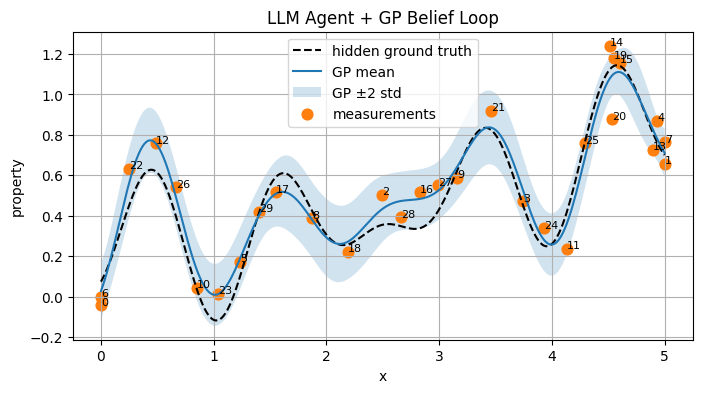

In [ ]:
gp, pred, gp_context = fit_gp_from_history(history, belief)

plt.figure(figsize=(8, 4))

# hidden truth, only for evaluation
plt.plot(x_grid, multimodal(x_grid), "k--", label="hidden ground truth")

plt.plot(x_grid, pred["mean"], label="GP mean")
plt.fill_between(
    x_grid,
    pred["mean"] - 2 * pred["std_latent"],
    pred["mean"] + 2 * pred["std_latent"],
    alpha=0.2,
    label="GP ±2 std"
)

plt.scatter(df_history["x"], df_history["y"], s=60, label="measurements")

for _, row in df_history.iterrows():
    plt.text(row["x"], row["y"], int(row["step"]), fontsize=8)

plt.xlabel("x")
plt.ylabel("property")
plt.title("LLM Agent + GP Belief Loop")
plt.grid(True)
plt.legend()
plt.show()

Time variance

In [ ]:
time_choices = np.array([0.05, 0.1, 0.25, 0.5, 1.0, 2.0, 4.0])

def ask_agent(history, gp_context, budget_remaining, step):
    last_times = [h["t"] for h in history[-3:]]

    prompt = f"""
You are an autonomous experimental design agent.

Goal:
Learn an unknown 1D material property function efficiently.

You do NOT know the ground truth or noise model.
You only know measurement history and GP belief state.

Current step: {step}
Budget remaining: {budget_remaining}

Recent measurement times:
{last_times}

Measurement history:
{history}

Current GP context:
{gp_context}

Allowed measurement times:
{time_choices.tolist()}

Time-selection rule:
- Use 0.05 or 0.1 for cheap exploration far from known points.
- Use 0.25 or 0.5 for normal measurements.
- Use 1.0 or 2.0 near promising extrema or confusing regions.
- Use 4.0 only when confirming the current predicted best location.
- Do NOT repeatedly choose the same time.

Choose the next experiment.

Return ONLY valid JSON:
{{
"x": float between 0 and 5,
"t": one of {time_choices.tolist()},
"belief": float between 0 and 1,
"reason": string
}}

Meaning of belief:
- high belief near 1 means trust measurements strongly
- low belief near 0 means assume measurements are noisy and fit smoother GP
"""
    response = client.responses.create(
        model="gpt-5-mini",
        input=prompt
    )
    return extract_json(response.output_text)

In [ ]:
history = []

seed_points = [(0.0, 0.5), (5.0, 0.5)]

budget_remaining = 30

for i, (x0, t0) in enumerate(seed_points):
    y0 = sim.measure(np.array([[x0, t0]]))[0]

    history.append({
        "step": i,
        "x": float(x0),
        "t": float(t0),
        "y": float(y0),
        "belief": 0.5,
        "budget_remaining": float(budget_remaining - t0),
        "reason": "seed point"
    })

    budget_remaining -= t0

belief = 0.5

for step in range(2, 30):

    if budget_remaining <= 1e-6:
        break

    gp, pred, gp_context = fit_gp_from_history(history, belief)

    action = ask_agent(history, gp_context, budget_remaining, step)

    x_next = float(np.clip(action["x"], 0, 5))

    # snap LLM time to allowed options
    t_raw = float(action["t"])
    t_next = float(time_choices[np.argmin(np.abs(time_choices - t_raw))])
    t_next = min(t_next, budget_remaining)

    # avoid repeating same time 3 times
    if len(history) >= 2:
        if history[-1]["t"] == history[-2]["t"] == t_next:
            alternatives = time_choices[time_choices != t_next]
            alternatives = alternatives[alternatives <= budget_remaining]
            if len(alternatives) > 0:
                t_next = float(alternatives[np.argmin(np.abs(alternatives - 0.25))])

    belief = float(np.clip(action["belief"], 0, 1))

    y_obs = sim.measure(np.array([[x_next, t_next]]))[0]

    history.append({
        "step": step,
        "x": x_next,
        "t": t_next,
        "y": float(y_obs),
        "belief": belief,
        "budget_remaining": float(budget_remaining - t_next),
        "gp_mean_std": gp_context["mean_std"],
        "gp_max_std": gp_context["max_std"],
        "gp_x_max_uncertainty": gp_context["x_max_uncertainty"],
        "gp_x_predicted_best": gp_context["x_predicted_best"],
        "reason": action["reason"]
    })

    budget_remaining -= t_next

    print(
        f"step={step:02d} | "
        f"x={x_next:.3f} | "
        f"t={t_next:.3f} | "
        f"belief={belief:.2f} | "
        f"y={y_obs:.3f} | "
        f"remaining={budget_remaining:.3f}"
    )

df_history = pd.DataFrame(history)
df_history

step=02 | x=2.490 | t=0.100 | belief=0.30 | y=0.095 | remaining=28.900
step=03 | x=3.750 | t=1.000 | belief=0.50 | y=0.407 | remaining=27.900
step=04 | x=1.250 | t=0.250 | belief=0.60 | y=-0.093 | remaining=27.650
step=05 | x=5.000 | t=2.000 | belief=0.85 | y=0.761 | remaining=25.650
step=06 | x=4.500 | t=1.000 | belief=0.70 | y=1.212 | remaining=24.650
step=07 | x=4.600 | t=0.500 | belief=0.75 | y=1.059 | remaining=24.150
step=08 | x=4.530 | t=1.000 | belief=0.80 | y=1.325 | remaining=23.150
step=09 | x=4.515 | t=2.000 | belief=0.90 | y=1.102 | remaining=21.150
step=10 | x=4.545 | t=1.000 | belief=0.80 | y=0.978 | remaining=20.150
step=11 | x=4.525 | t=0.500 | belief=0.75 | y=1.085 | remaining=19.650
step=12 | x=4.532 | t=2.000 | belief=0.90 | y=1.161 | remaining=17.650
step=13 | x=4.532 | t=4.000 | belief=0.95 | y=1.121 | remaining=13.650
step=14 | x=0.619 | t=0.100 | belief=0.40 | y=0.962 | remaining=13.550
step=15 | x=3.127 | t=0.050 | belief=0.35 | y=0.770 | remaining=13.500
step=

,step,x,t,y,belief,budget_remaining,reason,gp_mean_std,gp_max_std,gp_x_max_uncertainty,gp_x_predicted_best
0,0,0.000000,0.50,0.051321,0.50,29.50,seed point,NaN,NaN,NaN,NaN
1,1,5.000000,0.50,0.909422,0.50,29.00,seed point,NaN,NaN,NaN,NaN
2,2,2.490000,0.10,0.094673,0.30,28.90,Explore the region of maximum GP uncertainty (...,0.295428,0.323188,2.491639,5.000000
3,3,3.750000,1.00,0.407181,0.50,27.90,Sample near the GP's current highest-uncertain...,0.230899,0.250487,3.745819,5.000000
4,4,1.250000,0.25,-0.093253,0.60,27.65,Sample near the GP's current maximum-uncertain...,0.047067,0.063431,1.254181,5.000000
5,5,5.000000,2.00,0.761442,0.85,25.65,Confirm the GP-predicted best at x=5.0 with a ...,0.030982,0.038424,0.000000,5.000000
6,6,4.500000,1.00,1.212102,0.70,24.65,Probe near the current predicted best (x=5.0) ...,0.051433,0.065963,0.000000,5.000000
7,7,4.600000,0.50,1.059495,0.75,24.15,Probe just right of the current GP-predicted b...,0.187117,0.302521,0.618729,4.531773
8,8,4.530000,1.00,1.325472,0.80,23.15,Probe the GP-predicted best (x≈4.53) with a 1....,0.166899,0.271149,0.618729,4.531773
9,9,4.515000,2.00,1.102101,0.90,21.15,High-quality probe near the GP-predicted best ...,0.193735,0.315934,0.618729,4.515050


/usr/local/lib/python3.12/dist-packages/torch/_compile.py:54: UserWarning: optimizer contains a parameter group with duplicate parameters; in future, this will cause an error; see github.com/pytorch/pytorch/issues/40967 for more information
  return disable_fn(*args, **kwargs)


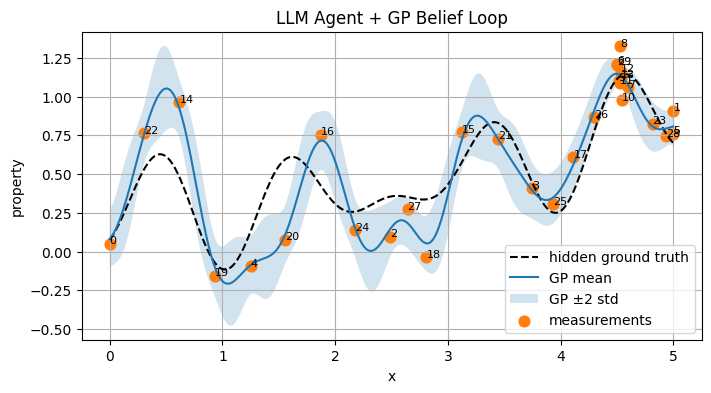

In [ ]:
gp, pred, gp_context = fit_gp_from_history(history, belief)

plt.figure(figsize=(8, 4))

# hidden truth, only for evaluation
plt.plot(x_grid, multimodal(x_grid), "k--", label="hidden ground truth")

plt.plot(x_grid, pred["mean"], label="GP mean")
plt.fill_between(
    x_grid,
    pred["mean"] - 2 * pred["std_latent"],
    pred["mean"] + 2 * pred["std_latent"],
    alpha=0.2,
    label="GP ±2 std"
)

plt.scatter(df_history["x"], df_history["y"], s=60, label="measurements")

for _, row in df_history.iterrows():
    plt.text(row["x"], row["y"], int(row["step"]), fontsize=8)

plt.xlabel("x")
plt.ylabel("property")
plt.title("LLM Agent + GP Belief Loop")
plt.grid(True)
plt.legend()
plt.show()

# **LLM chooses only time with Belief =0.6**

In [ ]:
def ask_agent(history, gp_context, budget_remaining, step):
    last_times = [h["t"] for h in history[-3:]]

    prompt = f"""
You are an autonomous experimental design agent.

Goal:
Learn an unknown 1D material property function efficiently.

We trust measurements with fixed GP belief = 0.6.

Current step: {step}
Budget remaining: {budget_remaining}

Recent measurement times:
{last_times}

Measurement history:
{history}

Current GP context:
{gp_context}

Allowed measurement times:
[0.05, 0.1, 0.25, 0.5, 1.0, 2.0, 4.0]

Time-selection rule:
- Use 0.05 or 0.1 for cheap exploration far from known points.
- Use 0.25 or 0.5 for normal measurements.
- Use 1.0 or 2.0 only near promising extrema or confusing regions.
- Use 4.0 only when confirming current predicted best location.
- Do NOT repeatedly choose the same time.
- If recent times include repeated 1.0, choose a different t.

Return ONLY valid JSON:
{{
"x": float between 0 and 5,
"t": one of [0.05, 0.1, 0.25, 0.5, 1.0, 2.0, 4.0],
"reason": string
}}
"""
    response = client.responses.create(
        model="gpt-5-mini",
        input=prompt
    )
    return extract_json(response.output_text)

In [ ]:
BELIEF_FIXED = 0.6
time_choices = np.array([0.05, 0.1, 0.25, 0.5, 1.0, 2.0, 4.0])

history = []

budget_total = B
budget_remaining = 30

seed_points = [
    (0.0, 0.5),
    (5.0, 0.5),
]

for i, (x0, t0) in enumerate(seed_points):
    coords = np.array([[x0, t0]])
    y0 = sim.measure(coords)[0]

    history.append({
        "step": i,
        "x": float(x0),
        "t": float(t0),
        "y": float(y0),
        "belief": BELIEF_FIXED,
        "budget_remaining": float(budget_remaining - t0),
        "reason": "seed point"
    })

    budget_remaining -= t0

n_steps = 30

for step in range(len(history), n_steps):

    if budget_remaining <= 1e-6:
        break

    gp, pred, gp_context = fit_gp_from_history(
        history,
        belief=BELIEF_FIXED
    )

    action = ask_agent(
        history=history,
        gp_context=gp_context,
        budget_remaining=budget_remaining,
        step=step
    )

    x_next = float(np.clip(action["x"], 0, 5))

    t_raw = float(action["t"])
    t_next = float(time_choices[np.argmin(np.abs(time_choices - t_raw))])
    t_next = min(t_next, budget_remaining)

    # hard rule: avoid repeating same time 3 times
    if len(history) >= 2:
        if history[-1]["t"] == history[-2]["t"] == t_next:
            alternatives = time_choices[time_choices != t_next]
            alternatives = alternatives[alternatives <= budget_remaining]
            if len(alternatives) > 0:
                t_next = float(alternatives[np.argmin(np.abs(alternatives - 0.25))])

    coords = np.array([[x_next, t_next]])
    y_obs = sim.measure(coords)[0]

    history.append({
        "step": step,
        "x": x_next,
        "t": t_next,
        "y": float(y_obs),
        "belief": BELIEF_FIXED,
        "budget_remaining": float(budget_remaining - t_next),
        "gp_mean_std": gp_context["mean_std"],
        "gp_max_std": gp_context["max_std"],
        "gp_x_max_uncertainty": gp_context["x_max_uncertainty"],
        "gp_x_predicted_best": gp_context["x_predicted_best"],
        "reason": action["reason"]
    })

    budget_remaining -= t_next

    print(
        f"step={step:02d} | "
        f"x={x_next:.3f} | "
        f"t={t_next:.3f} | "
        f"y={y_obs:.3f} | "
        f"remaining={budget_remaining:.3f}"
    )

df_history = pd.DataFrame(history)
df_history

step=02 | x=2.458 | t=0.100 | y=0.306 | remaining=28.900
step=03 | x=3.729 | t=0.250 | y=0.407 | remaining=28.650
step=04 | x=1.187 | t=0.050 | y=0.099 | remaining=28.600
step=05 | x=5.000 | t=4.000 | y=0.707 | remaining=24.600
step=06 | x=0.000 | t=0.100 | y=-0.062 | remaining=24.500
step=07 | x=2.525 | t=0.250 | y=0.437 | remaining=24.250
step=08 | x=5.000 | t=2.000 | y=0.774 | remaining=22.250
step=09 | x=1.800 | t=0.050 | y=0.538 | remaining=22.200
step=10 | x=3.813 | t=0.500 | y=0.599 | remaining=21.700
step=11 | x=0.000 | t=0.100 | y=0.162 | remaining=21.600
step=12 | x=0.000 | t=0.250 | y=0.045 | remaining=21.350
step=13 | x=5.000 | t=4.000 | y=0.705 | remaining=17.350
step=14 | x=0.000 | t=1.000 | y=0.010 | remaining=16.350
step=15 | x=5.000 | t=2.000 | y=0.623 | remaining=14.350
step=16 | x=0.000 | t=0.250 | y=0.166 | remaining=14.100
step=17 | x=5.000 | t=4.000 | y=0.655 | remaining=10.100
step=18 | x=2.475 | t=0.500 | y=0.295 | remaining=9.600
step=19 | x=0.000 | t=1.000 | y

,step,x,t,y,belief,budget_remaining,reason,gp_mean_std,gp_max_std,gp_x_max_uncertainty,gp_x_predicted_best
0,0,0.000000,0.50,0.268097,0.6,29.50,seed point,NaN,NaN,NaN,NaN
1,1,5.000000,0.50,0.858698,0.6,29.00,seed point,NaN,NaN,NaN,NaN
2,2,2.458194,0.10,0.305510,0.6,28.90,Probe region of highest GP uncertainty (x≈2.46...,0.191027,0.203735,2.458194,5.0
3,3,3.729097,0.25,0.407062,0.6,28.65,Probe the GP's highest-uncertainty location (~...,0.164290,0.179108,3.729097,5.0
4,4,1.187291,0.05,0.098515,0.6,28.60,Probe the GP's current highest-uncertainty loc...,0.135548,0.144776,1.187291,5.0
5,5,5.000000,4.00,0.707180,0.6,24.60,Confirm the GP's current predicted-best locati...,0.080498,0.096205,5.000000,5.0
6,6,0.000000,0.10,-0.061721,0.6,24.50,Probe the GP's current highest-uncertainty loc...,0.068382,0.085126,0.000000,5.0
7,7,2.525084,0.25,0.436714,0.6,24.25,Probe the GP's current maximum-uncertainty loc...,0.082393,0.087902,2.525084,5.0
8,8,5.000000,2.00,0.773923,0.6,22.25,Confirm the GP's current predicted-best locati...,0.072285,0.085534,5.000000,5.0
9,9,1.800000,0.05,0.538313,0.6,22.20,Cheap exploratory probe (t=0.05) to reduce unc...,0.064272,0.078831,0.000000,5.0


/usr/local/lib/python3.12/dist-packages/torch/_compile.py:54: UserWarning: optimizer contains a parameter group with duplicate parameters; in future, this will cause an error; see github.com/pytorch/pytorch/issues/40967 for more information
  return disable_fn(*args, **kwargs)


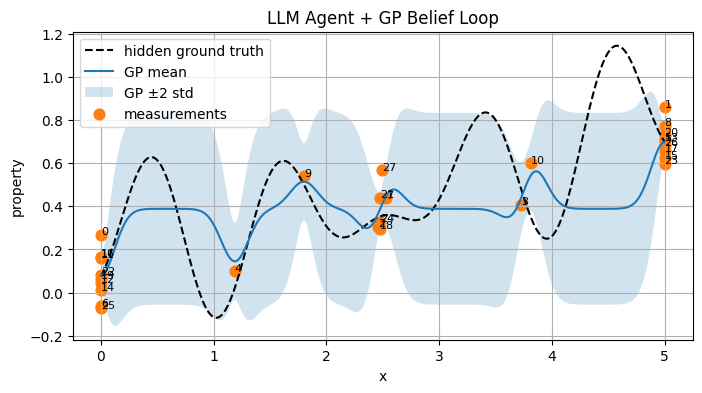

In [ ]:
gp, pred, gp_context = fit_gp_from_history(history, belief)

plt.figure(figsize=(8, 4))

# hidden truth, only for evaluation
plt.plot(x_grid, multimodal(x_grid), "k--", label="hidden ground truth")

plt.plot(x_grid, pred["mean"], label="GP mean")
plt.fill_between(
    x_grid,
    pred["mean"] - 2 * pred["std_latent"],
    pred["mean"] + 2 * pred["std_latent"],
    alpha=0.2,
    label="GP ±2 std"
)

plt.scatter(df_history["x"], df_history["y"], s=60, label="measurements")

for _, row in df_history.iterrows():
    plt.text(row["x"], row["y"], int(row["step"]), fontsize=8)

plt.xlabel("x")
plt.ylabel("property")
plt.title("LLM Agent + GP Belief Loop")
plt.grid(True)
plt.legend()
plt.show()

# Adding memory to agent

In [ ]:
agent_memory = []

In [ ]:
def ask_agent(history, agent_memory, gp_context, budget_remaining, step):
    last_times = [h["t"] for h in history[-3:]]

    prompt = f"""
You are an autonomous experimental design agent.

Goal:
Learn an unknown 1D material property function efficiently.

Recent measurement times:
{last_times}

Agent memory:
{agent_memory}

Recent measurement history:
{history[-8:]}

Current GP context:
{gp_context}

Budget remaining: {budget_remaining}

Allowed measurement times:
{time_choices.tolist()}

Return ONLY valid JSON:
{{
"x": float between 0 and 5,
"t": one of {time_choices.tolist()},
"belief": float between 0 and 1,
"reason": string,
"memory_update": string
}}
"""
    response = client.responses.create(
        model="gpt-5-mini",
        input=prompt
    )
    return extract_json(response.output_text)